# Clustering Individuals Based on Eating Habits and Lifestyle


## Notebook Title : Data Preprocessing & Modeling

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

In [41]:
df_raw=pd.read_csv("C:/Users/ASUS/Desktop/Fac/Obesity_Clustering_Project/Data/raw/obesity_raw.csv")

In [42]:
df_raw.shape

(2174, 17)

In [43]:
df_raw.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,18.000000,1.620000,55.000000,yes,yes,2.000000,3.0,Frequently,no,1.000000,no,1.00000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,37.063599,1.502609,75.279605,yes,yes,2.000000,3.0,Sometimes,no,1.759803,no,0.00000,0.000000,Sometimes,Automobile,Obesity_Type_I
2,Female,18.297229,1.637396,NaN,yes,yes,2.000000,1.999014,Sometimes,no,2.326165,no,0.00705,0.000000,no,Public_Transportation,Overweight_Level_I
3,Male,19.865895,1.760330,55.370700,yes,yes,2.120185,4.0,Sometimes,no,2.582165,no,-1.00000,1.510609,no,Automobile,Insufficient_Weight
4,Male,47.706100,1.743935,84.729197,yes,yes,2.535315,3.0,Sometimes,no,1.146595,no,0.31381,0.000000,no,Automobile,Overweight_Level_II


In [44]:
df_raw.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                                object
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

## Data Cleaning

---Duplication

In [45]:
df_raw=df_raw.drop_duplicates()
df_raw.shape

(2108, 17)

-----Catego Columns Values

In [46]:
#Gender col
df_raw['Gender']= df_raw['Gender'].str.strip().str.lower()
df_raw['Gender'].unique()


array(['female', 'male', 'f', 'm'], dtype=object)

In [47]:
df_raw['Gender']=df_raw['Gender'].replace({
    'female':'Female','male':'Male',
     'f' : 'Female','m':'Male'})

df_raw['Gender'].value_counts()

Gender
Male      1061
Female    1047
Name: count, dtype: int64

In [48]:
#fixing some catego cols format
def clean(x):
    return x.str.strip().str.capitalize()

catego=['CAEC', 'CALC', 'FAVC', 'SMOKE', 'SCC', 'family_history_with_overweight']

for col in catego:
    df_raw[col]=clean(df_raw[col])

for col in catego:
    print(f'**********{col}************')
    print(df_raw[col].unique())
    print()


**********CAEC************
['Frequently' 'Sometimes' 'Always' nan 'No']

**********CALC************
['No' 'Sometimes' 'Frequently' nan 'Always']

**********FAVC************
['Yes' 'No']

**********SMOKE************
['No' 'Yes']

**********SCC************
['No' nan 'Yes']

**********family_history_with_overweight************
['Yes' 'No']



In [49]:
#-----MTRANS col
df_raw['MTRANS']=df_raw['MTRANS'].str.strip()

Numeric Cols Fixing

In [50]:
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in num_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

In [51]:
df_raw.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

Fixing Unrealistic Values discovered by .describe()

In [52]:
#'Height' col
n=(df_raw['Height']>3).sum()
df_raw.loc[df_raw['Height'] > 3, 'Height'] = df_raw.loc[df_raw['Height'] > 3, 'Height'] / 100


In [53]:
# 'Age' col
n_age=((df_raw['Age']<10) | (df_raw['Age']>90)).sum()
df_raw.loc[(df_raw['Age'] < 10) | (df_raw['Age'] > 110), 'Age'] = np.nan


In [54]:
#'Weight' col
n_weight= ((df_raw['Weight'] < 20) | (df_raw['Weight'] > 200)).sum()
df_raw.loc[(df_raw['Weight'] < 20) | (df_raw['Weight'] > 200), 'Weight'] = np.nan


In [55]:
# 'FAF' col range(0-3) have to be
n_faf = ((df_raw['FAF'] < 0) | (df_raw['FAF'] > 3)).sum()
df_raw.loc[df_raw['FAF'] < 0, 'FAF'] = np.nan
df_raw.loc[df_raw['FAF'] > 3, 'FAF'] = np.nan


Missing Values

In [56]:
df_raw.isnull().sum()

Gender                              0
Age                               110
Height                            126
Weight                             89
family_history_with_overweight      0
FAVC                                0
FCVC                               83
NCP                                 5
CAEC                              126
SMOKE                               0
CH2O                              105
SCC                                63
FAF                               154
TUE                                 0
CALC                              105
MTRANS                             85
NObeyesdad                          0
dtype: int64

Num cols Missing Values


* first we have to check our cols distribution and see if they are symmetric or not so we will make a the safer choice btw median & mean

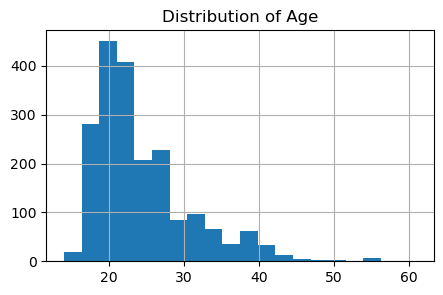

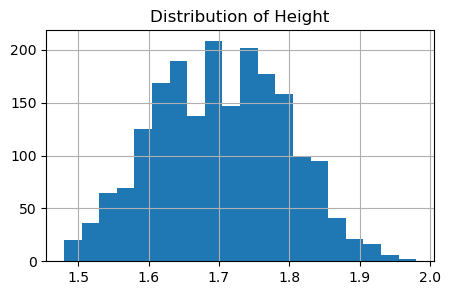

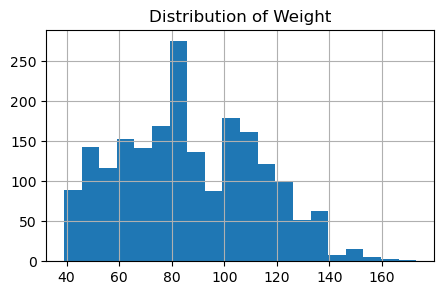

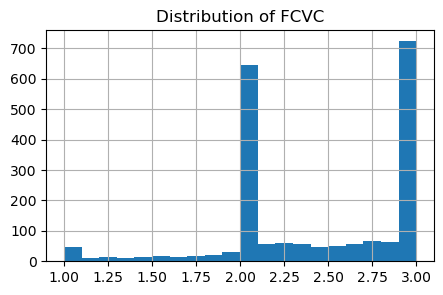

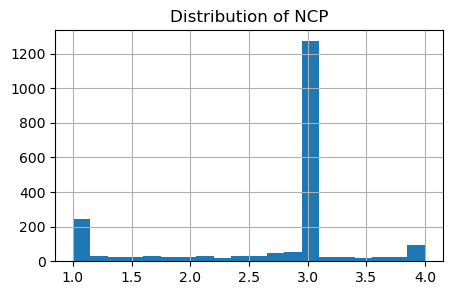

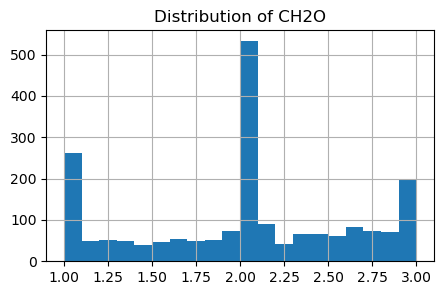

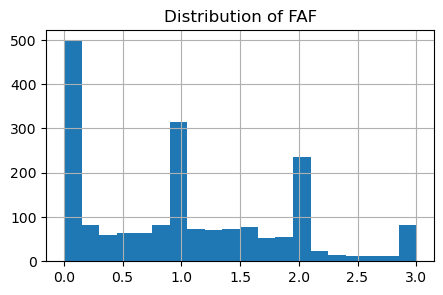

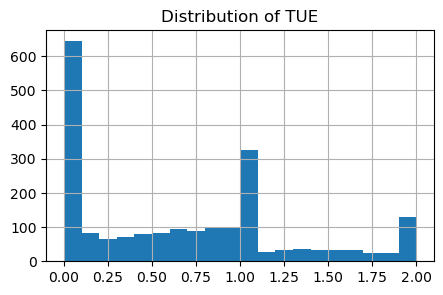

In [57]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    df_raw[col].hist(bins=20)
    plt.title(f'Distribution of {col}')
    plt.show()

In [58]:
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in num_cols:
    if df_raw[col].isnull().sum() > 0:
        median_val = df_raw[col].median()
        df_raw[col] = df_raw[col].fillna(median_val)

Missing values in our catego cols

* first whe have to check if our cols have balance distribution or not so will decide if we will use mode or not

In [59]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
            'SMOKE', 'SCC', 'CALC', 'MTRANS']
for col in cat_cols:
    print(df_raw[col].value_counts())
    print(f"null values: {df_raw[col].isnull().sum()}")
    print("*"*20)

Gender
Male      1061
Female    1047
Name: count, dtype: int64
null values: 0
********************
family_history_with_overweight
Yes    1733
No      375
Name: count, dtype: int64
null values: 0
********************
FAVC
Yes    1850
No      258
Name: count, dtype: int64
null values: 0
********************
CAEC
Sometimes     1645
Frequently     234
No              55
Always          48
Name: count, dtype: int64
null values: 126
********************
SMOKE
No     2062
Yes      46
Name: count, dtype: int64
null values: 0
********************
SCC
No     1951
Yes      94
Name: count, dtype: int64
null values: 63
********************
CALC
Sometimes     1323
No             613
Frequently      66
Always           1
Name: count, dtype: int64
null values: 105
********************
MTRANS
Public_Transportation    1515
Automobile                437
Walking                    55
Motorbike                   9
Bike                        7
Name: count, dtype: int64
null values: 85
********************


-->most distribution are skewed

In [60]:
#Catego cols
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
            'SMOKE', 'SCC', 'CALC', 'MTRANS']
for col in cat_cols:
    if df_raw[col].isnull().sum() > 0:
        mode_val = df_raw[col].mode()[0]
        df_raw[col] = df_raw[col].fillna(mode_val)

### recheck

In [61]:
df_raw.duplicated().sum()


np.int64(5)

In [62]:
df_raw=df_raw.drop_duplicates()


In [63]:
df_raw.shape

(2103, 17)

In [64]:
df_raw.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

In [65]:
df_raw.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [66]:
df_raw.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2103.000000,2103.000000,2103.000000,2103.000000,2103.000000,2103.000000,2103.000000,2103.000000
mean,24.260109,1.702484,86.728151,2.419976,2.696530,2.008916,1.016729,0.661625
std,6.233660,0.090235,25.648398,0.524848,0.768681,0.591413,0.819468,0.608282
min,14.000000,1.480000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.636248,67.041561,2.000000,2.693268,1.643794,0.195448,0.000000
50%,22.783646,1.701140,83.282232,2.397280,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.764150,106.184601,3.000000,3.000000,2.429485,1.592989,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [67]:
df_clean=df_raw.copy()

## Feature Engineering

**BMI : Body Mass Index**

it is an indicator of body fat or overweight risk

describe relation btw person's weight & height

In [68]:
df_clean['BMI'] = df_clean['Weight'] / (df_clean['Height'] ** 2)

def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df_clean['BMI_Category'] = df_clean['BMI'].apply(bmi_category)

print('BMI stats:')
print(df_clean['BMI'].describe())
print('*'*30)
print(df_clean['BMI_Category'].value_counts())

BMI stats:
count    2103.000000
mean       29.759352
std         7.954219
min        12.998685
25%        24.542161
50%        28.855798
75%        35.901785
max        53.429510
Name: BMI, dtype: float64
******************************
BMI_Category
Obese          975
Overweight     575
Normal         293
Underweight    260
Name: count, dtype: int64


**Activity Score**

describe the combo btw physical activity + transportation - screen time

we will rate a person if he maintains obesity an active lifestyle from 0 to 3

In [69]:
df_clean['MTRANS'].unique()

array(['Public_Transportation', 'Automobile', 'Walking', 'Bike',
       'Motorbike'], dtype=object)

In [70]:
mtrans_activity = {
    'Walking': 3, 'Bike': 2, 'Public_Transportation': 1,
    'Automobile': 0, 'Motorbike': 0
}
df_clean['MTRANS_score'] = df_clean['MTRANS'].map(mtrans_activity)
df_clean['Activity_Score'] = df_clean['FAF'] + df_clean['MTRANS_score'] - df_clean['TUE']
min_val = df_clean['Activity_Score'].min()
max_val = df_clean['Activity_Score'].max()


In [71]:
print(min_val,max_val)

-2.0 6.0


In [72]:
#range(0-3)
df_clean['Activity_Score'] = df_clean['Activity_Score'].clip(lower=0, upper=3).astype(int)

print(df_clean['Activity_Score'].describe())

count    2103.000000
mean        0.908702
std         0.919311
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: Activity_Score, dtype: float64


**Risk Score**

Describe the unhealthy habits by combining the consumption of high caloric food as well as eating food btw meals 'CAEC'

In [73]:
df_clean['CAEC'].unique()

array(['Frequently', 'Sometimes', 'Always', 'No'], dtype=object)

In [74]:
df_clean['FAVC'].unique()

array(['Yes', 'No'], dtype=object)

In [75]:
# --- Convert FAVC to 0/1
df_clean['FAVC_bin'] = (df_clean['FAVC'].str.lower() == 'yes').astype(int)

df_clean['CAEC_score'] = df_clean['CAEC'].map({
    'No': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3
})

# range (0 to 4) 
df_clean['Risk_Score'] = df_clean['FAVC_bin'] + df_clean['CAEC_score']

# scale to range (0-3)
df_clean['Risk_Score'] = df_clean['Risk_Score'].clip(upper=3)

print(df_clean['Risk_Score'].value_counts().sort_index())

Risk_Score
0       8
1     223
2    1653
3     219
Name: count, dtype: int64


In [76]:
df_clean.to_csv("C:/Users/ASUS/Desktop/Fac/Obesity_Clustering_Project/Data/processed/df_processed.csv", index=False)

## Data Modeling

Splitting Data

In [77]:
#just to verify and make interpretation later since we have unsupervided learning
Target=df_clean['NObeyesdad'].copy 




X=df_clean.drop(columns=['NObeyesdad','BMI_Category','MTRANS_score','FAVC_bin','CAEC_score',])

we will drop some columns since they are already derived from others and may have redundant info so this will impact on ur models later for the clustering part 

In [78]:
X.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
BMI                               float64
Activity_Score                      int64
Risk_Score                          int64
dtype: object

Encoding

In [79]:
X_enco = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X_enco.shape)

Shape after encoding: (2103, 26)


In [80]:
X_enco.dtypes

Age                                   float64
Height                                float64
Weight                                float64
FCVC                                  float64
NCP                                   float64
CH2O                                  float64
FAF                                   float64
TUE                                   float64
BMI                                   float64
Activity_Score                          int64
Risk_Score                              int64
Gender_Male                              bool
family_history_with_overweight_Yes       bool
FAVC_Yes                                 bool
CAEC_Frequently                          bool
CAEC_No                                  bool
CAEC_Sometimes                           bool
SMOKE_Yes                                bool
SCC_Yes                                  bool
CALC_Frequently                          bool
CALC_No                                  bool
CALC_Sometimes                    

Feature Scaling

In [81]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enco)

Dimension Reducation

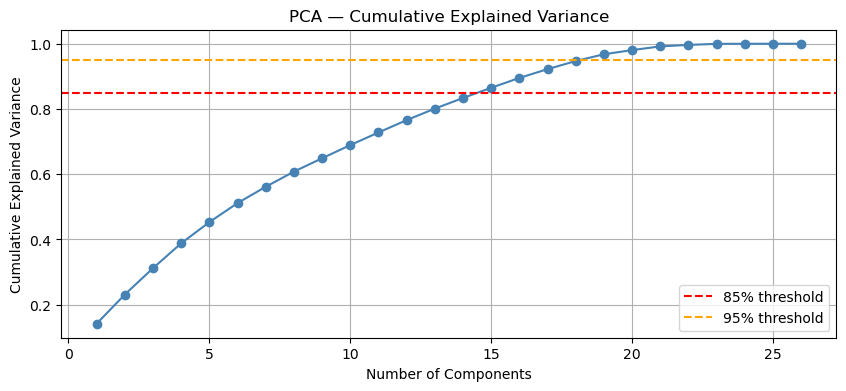

Components for 85% variance: 15
Components for 95% variance: 19


In [82]:
pca = PCA()
x_p=pca.fit(X_scaled)

#Cumulative  variance 
cum_var = np.cumsum(x_p.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='steelblue')
plt.axhline(0.85, color='red', linestyle='--', label='85% threshold')
plt.axhline(0.95, color='orange', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# needed components for each variance
n_85 = np.argmax(cum_var >= 0.85) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f'Components for 85% variance: {n_85}')
print(f'Components for 95% variance: {n_95}')

Explained variance ratio: [0.14182837 0.08947586]
Total explained variance (2 components): 23.13%


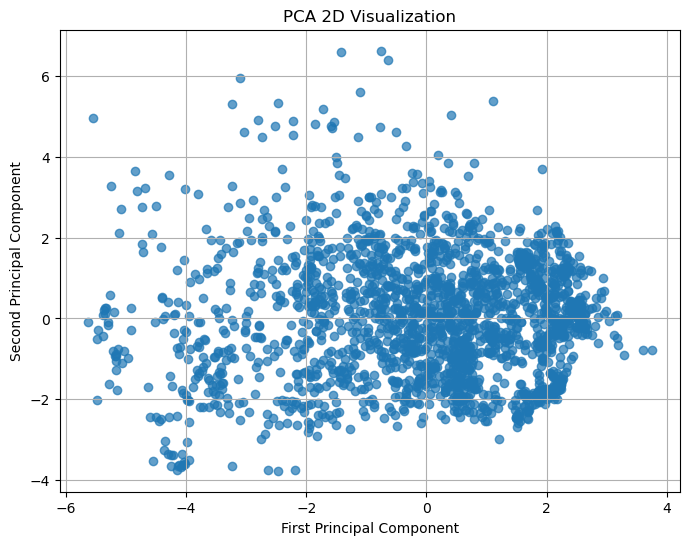

In [83]:
# PCA Visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)  

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance (2 components): {sum(pca.explained_variance_ratio_):.2%}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA 2D Visualization')
plt.grid(True)
plt.show()

-->The first two principal components explain only 23.13% of the total variance, indicating that the dataset has a complex structure with information distributed across many dimensions. 

## Choosing numbers of clusters 

**Silhouette Score**

measures how well each point fits into its cluster. It combines cohesion and separation.


Values :

Close to 1: good separation

Close to 0: clusters overlap

Negative: poor clustering

**Inertia (Elbow Method)**

Sum of the squared distances of the points to their centroid.measures how tight your clusters are.


low inertia -->good-->points close to their centers

high inertia -->points far from their cluster centers

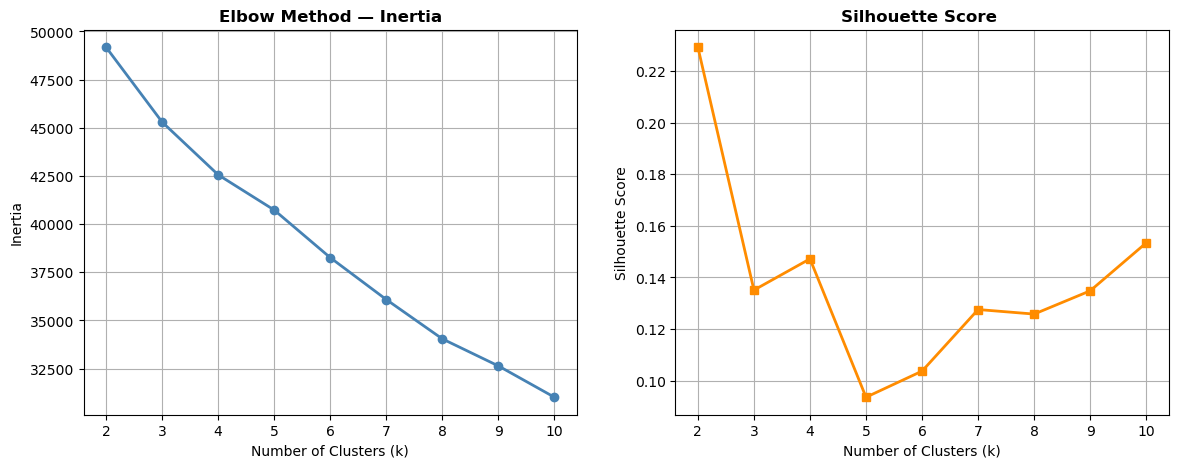

In [84]:
k_range = range(2, 11)

#evaluation metrics(silhouette/ inertia)
inertias = []     
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)

    #inertia
    inertias.append(km.inertia_)

    #Silhouette
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Inertia (Elbow Method)
axes[0].plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

#Silhouette score
axes[1].plot(k_range, sil_scores, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score ', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)


**Interpretation**

**Inertia** : most decreasing btw 2 & 4 then inertia remain constant

**silhouette**: peak value for silhouette is at 2

In [85]:
print(inertias)

[49182.08025804191, 45299.583640924975, 42560.582193164286, 40732.29009463742, 38261.98915761714, 36085.91468006157, 34044.80917367622, 32640.838446556438, 31016.327055028276]


In [86]:
print(sil_scores)

[0.2292610353000525, 0.1350960317510086, 0.14720980381599397, 0.09356432847892103, 0.10368761914805565, 0.12756336759813414, 0.1257986373212079, 0.134820372221282, 0.1534192110638539]


In [87]:
sil = []
for n in [10, 20, 50, 100]:
    km = KMeans(n_clusters=5, n_init=n, random_state=42)
    km.fit(X_scaled)
    sil.append(silhouette_score(X_scaled, km.labels_))

print(sil)

[0.09356432847892103, 0.1271372660103539, 0.13948860703845967, 0.15393174799866377]


The silhouette score barely changes when increasing n_init.

---> with n_init=10i have stable clustering

In [88]:
best_k = k_range[np.argmax(sil_scores)]
print(f'Best k by silhouette score: {best_k} (score = {max(sil_scores):.4f})')

Best k by silhouette score: 2 (score = 0.2293)


##  Model 1 — K-Means Clustering

In [89]:
K = best_k  # use best k found above

kmeans = KMeans(n_clusters=K, random_state=42, n_init=15)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, kmeans_labels)
db_km = davies_bouldin_score(X_scaled, kmeans_labels)

print(f'K-Means (k={K})')
print(f'  Silhouette Score : {sil_km:.4f}  (higher is better, max=1)')
print(f'  Davies-Bouldin   : {db_km:.4f}  (lower is better)')
print(f'  Cluster sizes    : {pd.Series(kmeans_labels).value_counts().sort_index().to_dict()}')

K-Means (k=2)
  Silhouette Score : 0.2293  (higher is better, max=1)
  Davies-Bouldin   : 2.6671  (lower is better)
  Cluster sizes    : {0: 1564, 1: 539}


In [90]:
pd.crosstab(kmeans_labels, df_clean['NObeyesdad'])

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,70,68,344,294,325,198,265
1,200,218,9,3,0,82,27


* **Cluster 0** : contains obesity types as well as the overweight levels 
>Cluster 0 -> heavier / obese group

* **Cluster 1** : contains mostly Insufficient_weight + Normal_Weight 
>Cluster 1 --> under/normal weight group

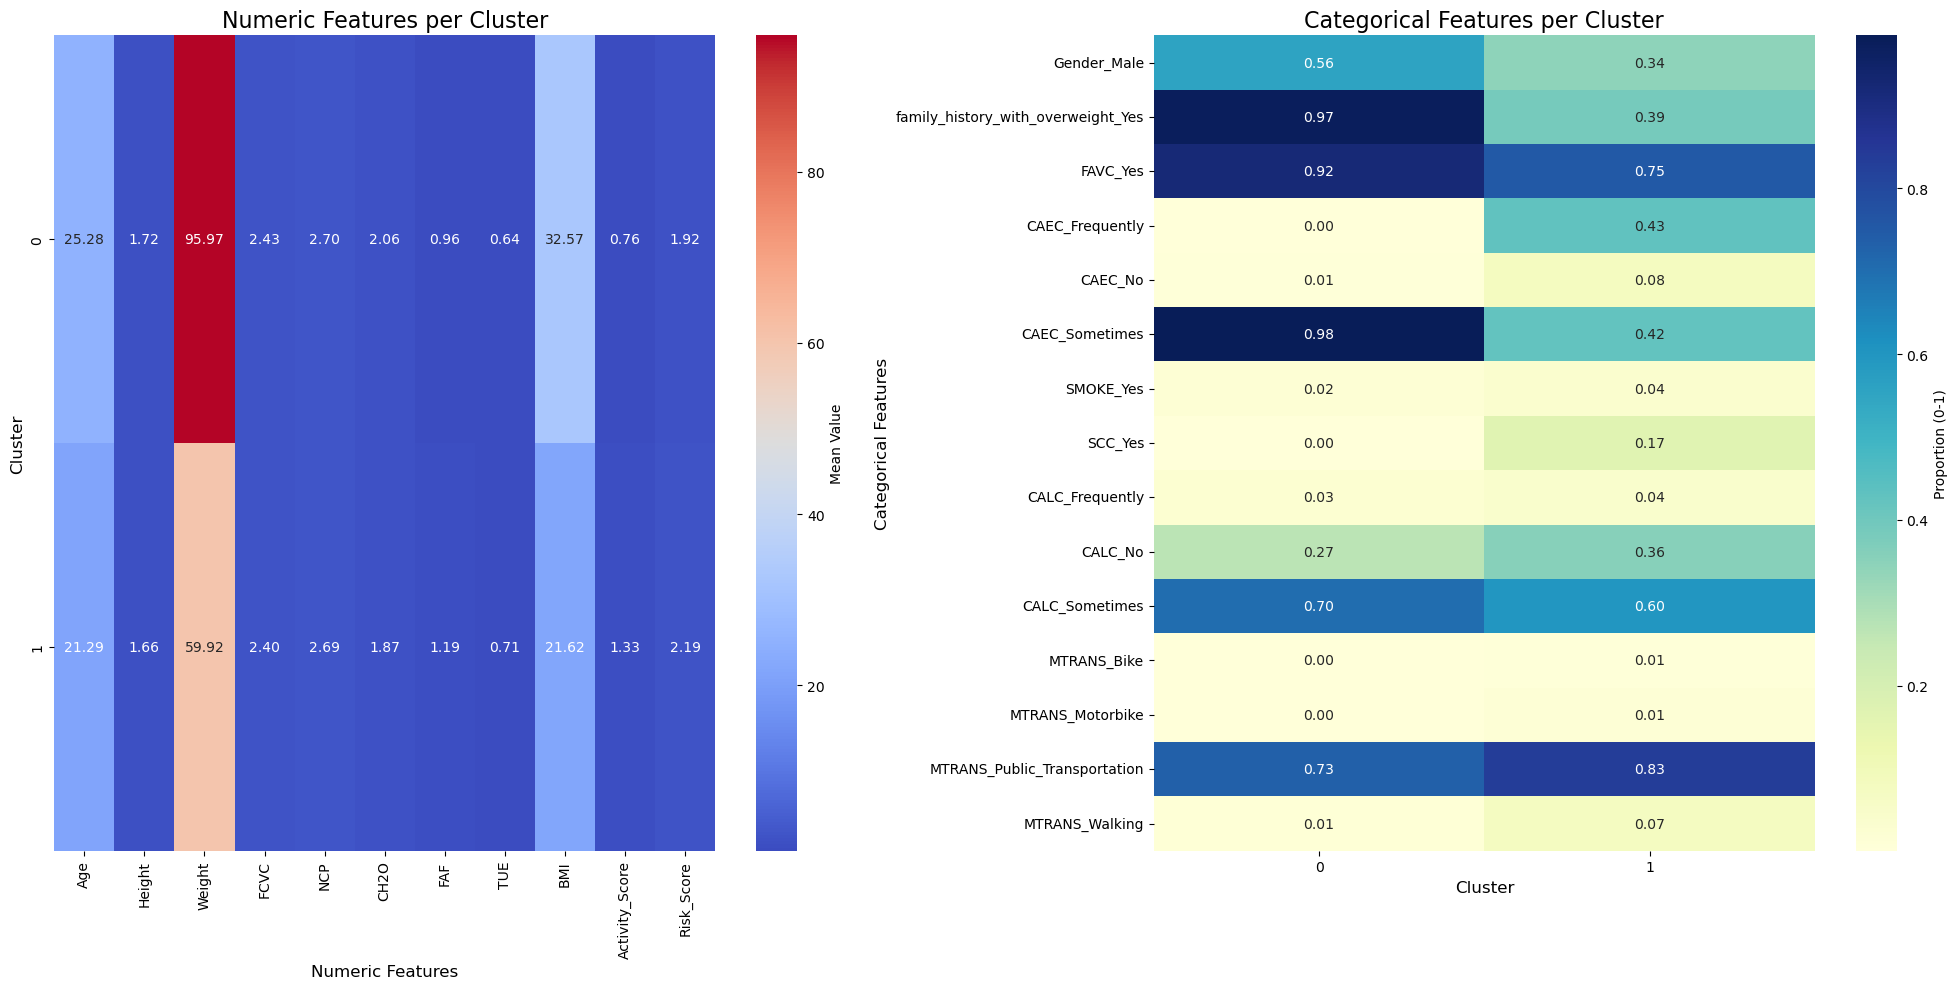

In [91]:
#Select numeric features
numeric_features = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE','BMI','Activity_Score','Risk_Score']

cluster_means_numeric = X_enco.groupby(kmeans_labels)[numeric_features].mean()

#categorical  features

categorical_features = [col for col in X_enco.columns 
                        if col not in numeric_features and X_enco[col].nunique() == 2]

cluster_props = X_enco.groupby(kmeans_labels)[categorical_features].mean()


fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# ----- Numeric features heatmap -----
sns.heatmap(cluster_means_numeric, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[0], cbar_kws={'label': 'Mean Value'})
axes[0].set_title("Numeric Features per Cluster", fontsize=16)
axes[0].set_xlabel("Numeric Features", fontsize=12)
axes[0].set_ylabel("Cluster", fontsize=12)

# ----- Categorical features heatmap -----
sns.heatmap(cluster_props.T, annot=True, fmt=".2f", cmap="YlGnBu",
            ax=axes[1], cbar_kws={'label': 'Proportion (0-1)'})
axes[1].set_title("Categorical Features per Cluster", fontsize=16)
axes[1].set_xlabel("Cluster", fontsize=12)
axes[1].set_ylabel("Categorical Features", fontsize=12)

plt.tight_layout()
plt.show()

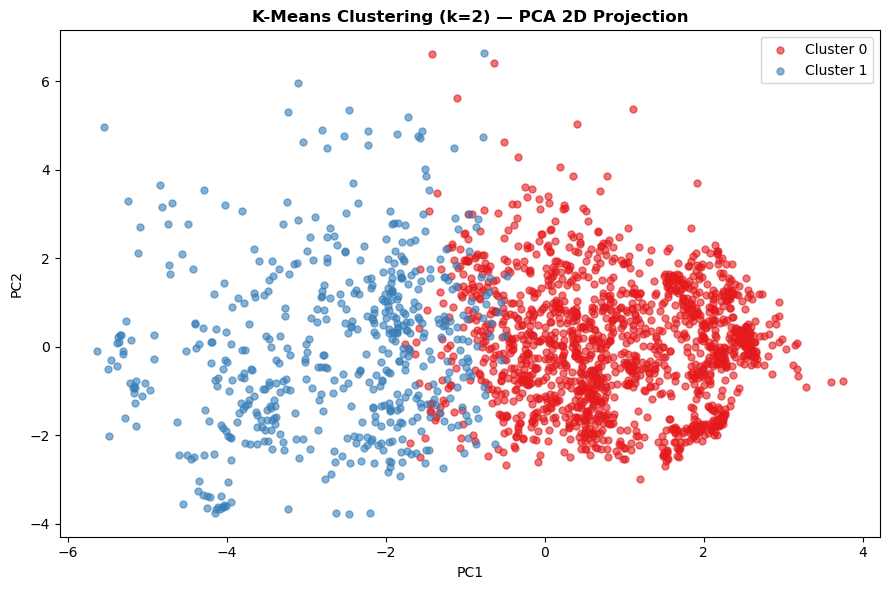

In [92]:
# Visualize K-Means in PCA 2D space
plt.figure(figsize=(9, 6))
palette = sns.color_palette('Set1', K)
for cluster in range(K):
    mask = kmeans_labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster}',
                alpha=0.6, s=25, color=palette[cluster])

plt.title(f'K-Means Clustering (k={K}) — PCA 2D Projection', fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

##  Model 2 — Hierarchical Clustering

In [93]:
for method in ['ward', 'complete', 'average']:
    for k in range(2, 12):
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        print(f"{method} - k={k} → {sil:.4f}")

ward - k=2 → 0.1301
ward - k=3 → 0.1428
ward - k=4 → 0.1497
ward - k=5 → 0.1427
ward - k=6 → 0.1323
ward - k=7 → 0.1384
ward - k=8 → 0.1459
ward - k=9 → 0.1540
ward - k=10 → 0.1564
ward - k=11 → 0.1651
complete - k=2 → 0.6507
complete - k=3 → 0.6229
complete - k=4 → 0.3539
complete - k=5 → 0.3567
complete - k=6 → 0.3651
complete - k=7 → 0.3513
complete - k=8 → 0.3335
complete - k=9 → 0.3024
complete - k=10 → 0.3026
complete - k=11 → 0.3028
average - k=2 → 0.6507
average - k=3 → 0.6229
average - k=4 → 0.5232
average - k=5 → 0.4999
average - k=6 → 0.4887
average - k=7 → 0.4438
average - k=8 → 0.4428
average - k=9 → 0.3727
average - k=10 → 0.3311
average - k=11 → 0.3372


according to the previous results 
* Ward method is not suitable  → silhouette is low → clusters not distinct
* Complete or average is better → silhouette is high → clusters are compact and well-separated

**Ward**

Threshold distance: 23.61


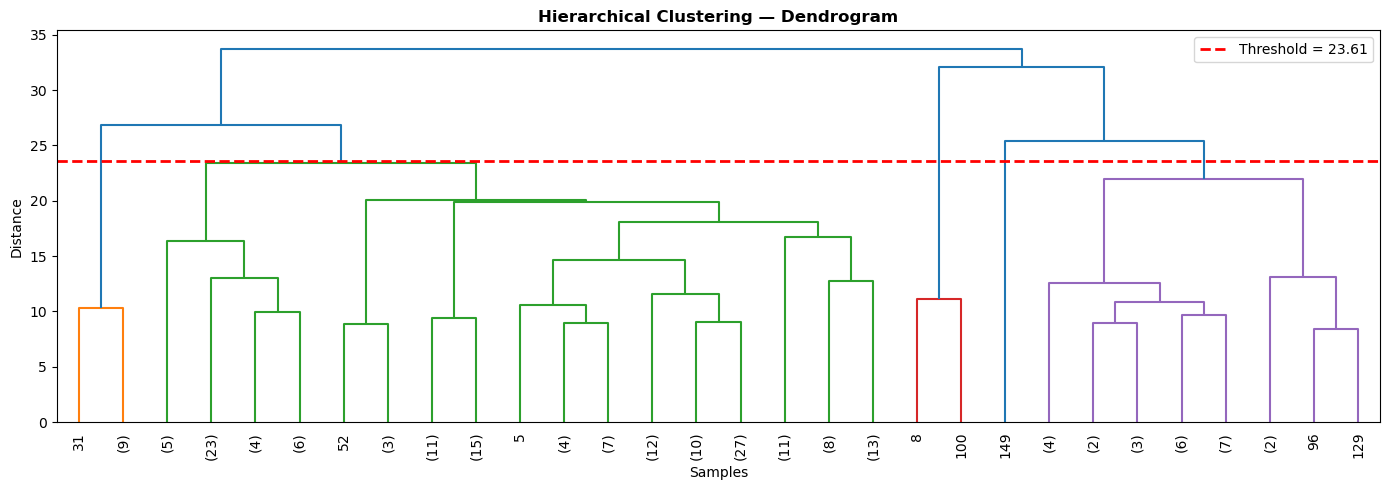

In [94]:
np.random.seed(42)

sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

threshold = 0.7 * max(Z[:, 2])
print(f"Threshold distance: {threshold:.2f}")

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,color_threshold=threshold)

plt.axhline(y=threshold, color='red', linestyle='--', lw=2, label=f'Threshold = {threshold:.2f}')

plt.title('Hierarchical Clustering — Dendrogram', fontweight='bold')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

sil_agg_h = silhouette_score(X_scaled, agg_labels)
db_agg_h = davies_bouldin_score(X_scaled, agg_labels)

print(f'Hierarchical Clustering (k={5}, ward linkage)')
print(f'  Silhouette Score : {sil_agg_h:.4f}')
print(f'  Davies-Bouldin   : {db_agg_h:.4f}')
print(f'  Cluster sizes    : {pd.Series(agg_labels).value_counts().sort_index().to_dict()}')

Hierarchical Clustering (k=5, ward linkage)
  Silhouette Score : 0.1427
  Davies-Bouldin   : 2.1264
  Cluster sizes    : {0: 1159, 1: 60, 2: 219, 3: 52, 4: 613}


In [96]:
agg = AgglomerativeClustering(n_clusters=K, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

sil_agg_h = silhouette_score(X_scaled, agg_labels)
db_agg_h = davies_bouldin_score(X_scaled, agg_labels)

print(f'Hierarchical Clustering (k={K}, ward linkage)')
print(f'  Silhouette Score : {sil_agg_h:.4f}')
print(f'  Davies-Bouldin   : {db_agg_h:.4f}')
print(f'  Cluster sizes    : {pd.Series(agg_labels).value_counts().sort_index().to_dict()}')

Hierarchical Clustering (k=2, ward linkage)
  Silhouette Score : 0.1301
  Davies-Bouldin   : 3.1020
  Cluster sizes    : {0: 944, 1: 1159}


======================Interpretation

since hierarchical clustering starts with unkonwn nbr of cluster 

first we had choose K=5 based on the dendrogram 
>K=5 → slightly higher silhouette (0.1427), but tiny clusters exist

Second we tried the best k founded previously by interia and sil score 
>K=2 → balanced clusters, silhouette 0.1301

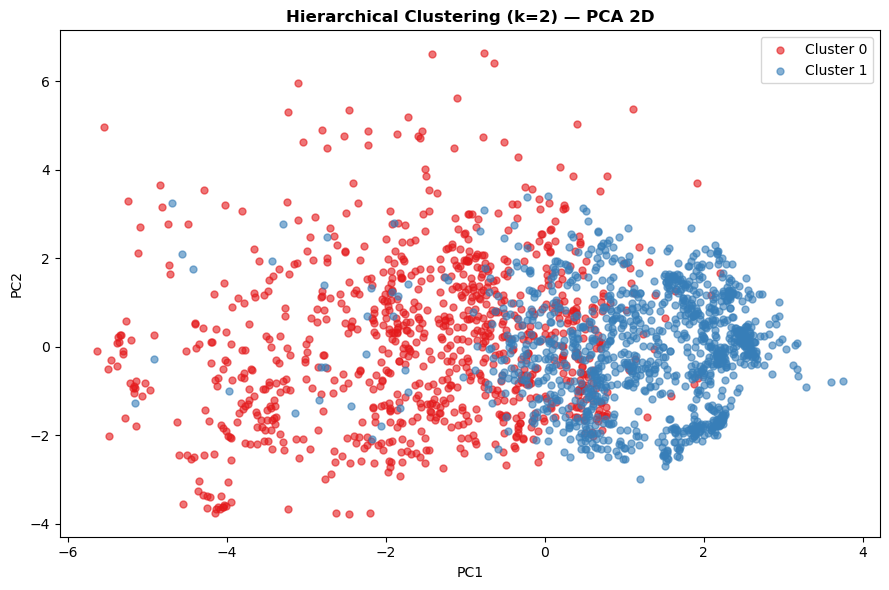

In [97]:
# Visualize
plt.figure(figsize=(9, 6))
for cluster in range(K):
    mask = agg_labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster}',
                alpha=0.6, s=25, color=palette[cluster])

plt.title(f'Hierarchical Clustering (k={K}) — PCA 2D', fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

**Complete**

Threshold distance: 17.91


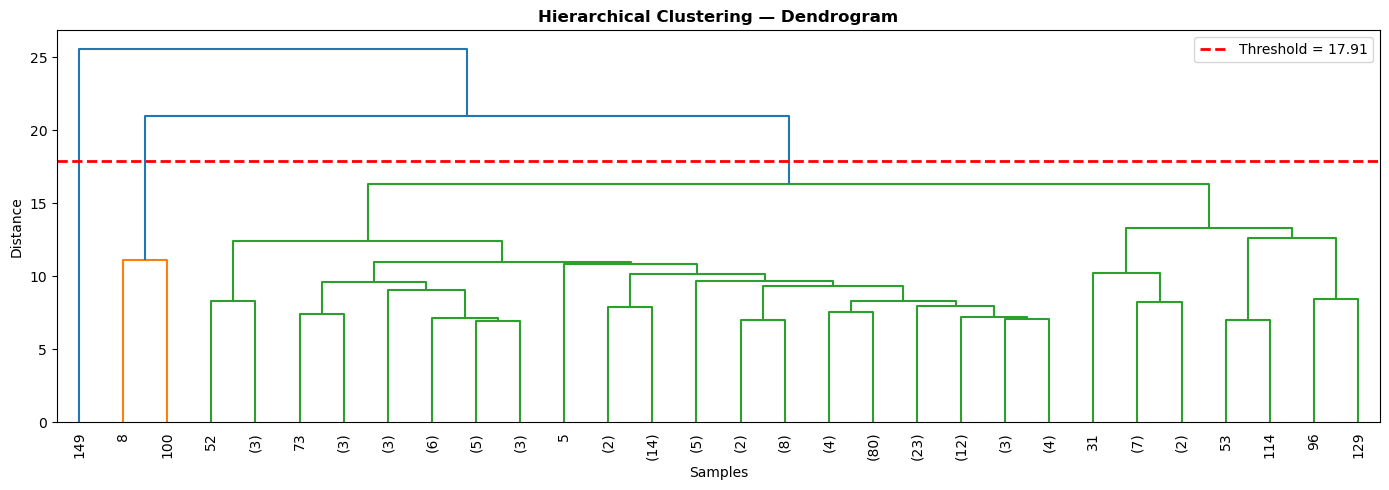

In [98]:
np.random.seed(42)

sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='complete')

threshold = 0.7 * max(Z[:, 2])
print(f"Threshold distance: {threshold:.2f}")

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,color_threshold=threshold)

plt.axhline(y=threshold, color='red', linestyle='--', lw=2, label=f'Threshold = {threshold:.2f}')

plt.title('Hierarchical Clustering — Dendrogram', fontweight='bold')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
agg = AgglomerativeClustering(n_clusters=K, linkage='complete')
agg_labels = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, agg_labels)
db_agg = davies_bouldin_score(X_scaled, agg_labels)

print(f'Hierarchical Clustering (k={K}, ward linkage)')
print(f'  Silhouette Score : {sil_agg:.4f}')
print(f'  Davies-Bouldin   : {db_agg:.4f}')
print(f'  Cluster sizes    : {pd.Series(agg_labels).value_counts().sort_index().to_dict()}')

Hierarchical Clustering (k=2, ward linkage)
  Silhouette Score : 0.6507
  Davies-Bouldin   : 0.4956
  Cluster sizes    : {0: 2096, 1: 7}


===================

Although the 'complete' method gave us before slightly better silhouette score but we can't used it since it gives us strongly unbalanced and unmeaningful cluters

===========

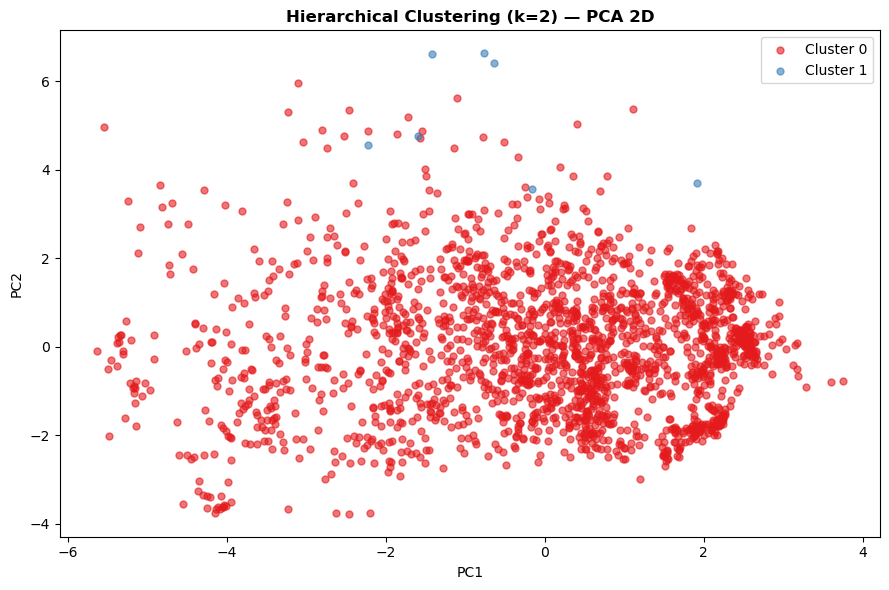

In [100]:
# Visualize
plt.figure(figsize=(9, 6))
for cluster in range(K):
    mask = agg_labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster}',
                alpha=0.6, s=25, color=palette[cluster])

plt.title(f'Hierarchical Clustering (k={K}) — PCA 2D', fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

## Model 3 — DBSCAN

* k (min_samples): Minimum number of points needed to form a dense region.
* eps: Radius for a point to consider neighbors. Automatically estimated from the top 90–95% distances in the k-distance graph.
* Clusters: Number of clusters DBSCAN found (excluding noise).
* Noise points: Points labeled as -1 by DBSCAN.
* Silhouette: How well-separated the clusters are (only computed if ≥2 clusters).

K Testing


--- Testing k = 5 ---


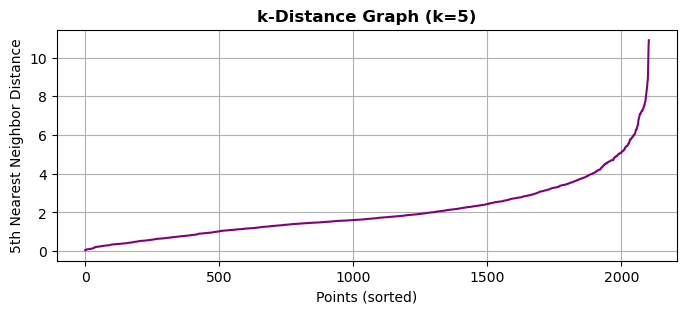

Chosen eps: 4.5205
Number of clusters: 9
Number of noise points: 120
Silhouette score: 0.20626892717702516

--- Testing k = 10 ---


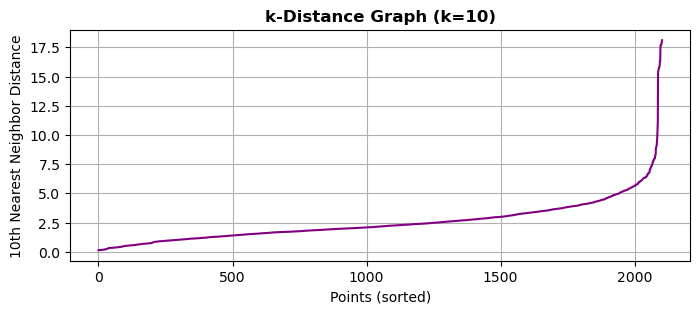

Chosen eps: 5.0538
Number of clusters: 5
Number of noise points: 106
Silhouette score: 0.268803297483612

--- Testing k = 20 ---


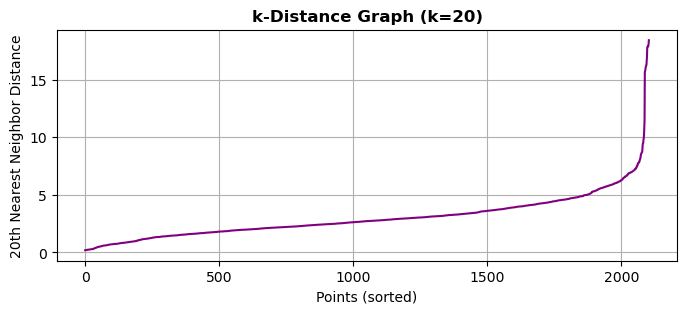

Chosen eps: 5.7320
Number of clusters: 5
Number of noise points: 72
Silhouette score: 0.28255155037969976

--- Testing k = 52 ---


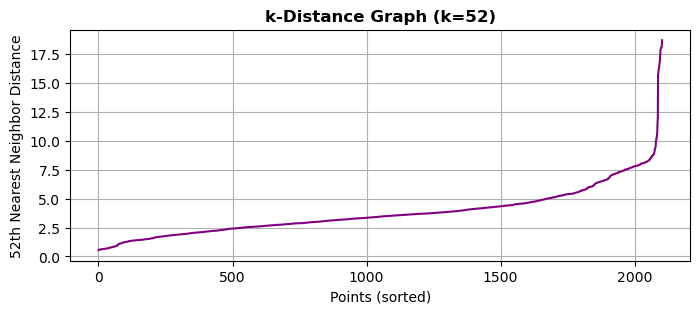

Chosen eps: 7.2792
Number of clusters: 1
Number of noise points: 80
Silhouette score: nan


In [101]:
# test a list of k
k_values = [5, 10, 20, 52]

results = {}

for k in k_values:
    print(f"\n--- Testing k = {k} ---")
    
    #identify k-distance
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X_scaled)
    distances, _ = neighbors.kneighbors(X_scaled)
    distances_sorted = np.sort(distances[:, -1])  # distance to k-th neighbor
    
    #Plot 
    plt.figure(figsize=(8,3))
    plt.plot(distances_sorted, color='purple')
    plt.title(f'k-Distance Graph (k={k})', fontweight='bold')
    plt.xlabel('Points (sorted)')
    plt.ylabel(f'{k}th Nearest Neighbor Distance')
    plt.grid(True)
    plt.show()
    
    
    start_idx = int(len(distances_sorted) * 0.90)
    end_idx = int(len(distances_sorted) * 0.95)
    eps = np.mean(distances_sorted[start_idx:end_idx])
    
    db = DBSCAN(eps=eps, min_samples=k)
    labels = db.fit_predict(X_scaled)
    
    #nbr of clusters, noise, silhouette
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    if n_clusters >= 2:
        score = silhouette_score(X_scaled, labels)
    else:
        score = np.nan  
    
    results[k] = {
        "eps": eps,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": score,
        "labels": labels
    }
    
    print(f"Chosen eps: {eps:.4f}")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise}")
    print(f"Silhouette score: {score}")

Eps Search

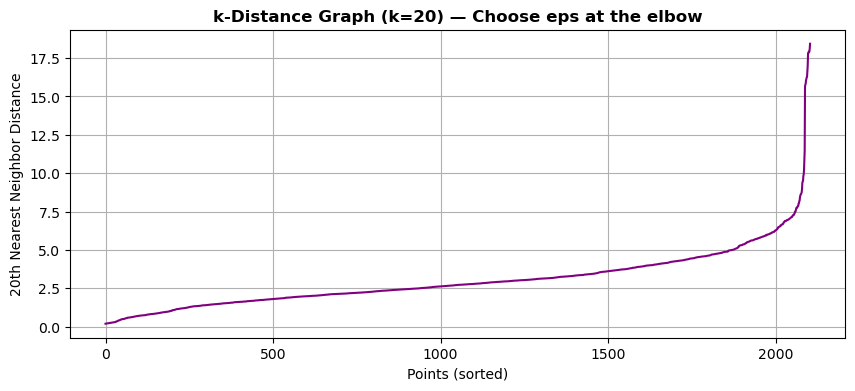

In [102]:
#  min_samples = 20 (based on k test)
min_samples = 20
n_features = X_scaled.shape[1]

#k-distance 
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, -1])  # distance to k-th neighbor

# Plot 
plt.figure(figsize=(10,4))
plt.plot(distances_sorted, color='purple')
plt.title(f'k-Distance Graph (k={min_samples}) — Choose eps at the elbow', fontweight='bold')
plt.xlabel('Points (sorted)')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

# ----------------------------
# Step 2: Automatically define eps range around elbow
start_idx = int(len(distances_sorted) * 0.90)
end_idx   = int(len(distances_sorted) * 0.95)
eps_values = np.linspace(distances_sorted[start_idx], distances_sorted[end_idx], 6)

# Step 3: Test min_samples variations (optional)
min_samples_values = [min_samples-1, min_samples, min_samples+1]



rechecking

In [103]:
# Grid search DBSCAN with silhouette score
best_score = -1
best_params = None

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  
        if n_clusters > 1:  
            score = silhouette_score(X_scaled, labels)
            print(f"eps={eps:.2f}, min_samples={ms}, clusters={n_clusters}, silhouette={score:.4f}")
            if score > best_score:
                best_score = score
                best_params = (eps, ms)

#Best parameters
if best_params is not None:
    print(f"\nBest parameters: eps={best_params[0]:.2f}, min_samples={best_params[1]}, silhouette={best_score:.4f}")
else:
    print("\nNo valid clusters found. Consider increasing eps.")



eps=5.28, min_samples=19, clusters=4, silhouette=0.2708
eps=5.28, min_samples=20, clusters=4, silhouette=0.2672
eps=5.28, min_samples=21, clusters=4, silhouette=0.2672
eps=5.47, min_samples=19, clusters=5, silhouette=0.2741
eps=5.47, min_samples=20, clusters=5, silhouette=0.2741
eps=5.47, min_samples=21, clusters=5, silhouette=0.2741
eps=5.66, min_samples=19, clusters=5, silhouette=0.2828
eps=5.66, min_samples=20, clusters=5, silhouette=0.2826
eps=5.66, min_samples=21, clusters=5, silhouette=0.2811
eps=5.85, min_samples=19, clusters=5, silhouette=0.2851
eps=5.85, min_samples=20, clusters=5, silhouette=0.2841
eps=5.85, min_samples=21, clusters=5, silhouette=0.2839
eps=6.04, min_samples=19, clusters=5, silhouette=0.2910
eps=6.04, min_samples=20, clusters=5, silhouette=0.2910
eps=6.04, min_samples=21, clusters=5, silhouette=0.2907
eps=6.23, min_samples=19, clusters=4, silhouette=0.3275
eps=6.23, min_samples=20, clusters=4, silhouette=0.3275
eps=6.23, min_samples=21, clusters=4, silhouette

fit dbscan on our choosen param

In [104]:
db_best = DBSCAN(eps=best_params[0], min_samples=best_params[1])
labels_best = db_best.fit_predict(X_scaled)

n_clusters_db = len(set(labels_best)) - (1 if -1 in labels_best else 0)
n_noise = (labels_best == -1).sum()

print(f'DBSCAN (eps=6.23, min_samples=19)')
print(f'  Clusters found   : {n_clusters_db}')
print(f'  Noise points (-1): {n_noise} ({n_noise/len(labels_best)*100:.1f}%)')

if n_clusters_db > 1:
    # Only compute silhouette on non-noise points
    mask_valid = labels_best != -1
    sil_db = silhouette_score(X_scaled[mask_valid], labels_best[mask_valid])
    print(f'  Silhouette Score : {sil_db:.4f} (excluding noise)')
else:
    print('Only 1 cluster — try adjusting eps')

DBSCAN (eps=6.23, min_samples=19)
  Clusters found   : 4
  Noise points (-1): 48 (2.3%)
  Silhouette Score : 0.3412 (excluding noise)


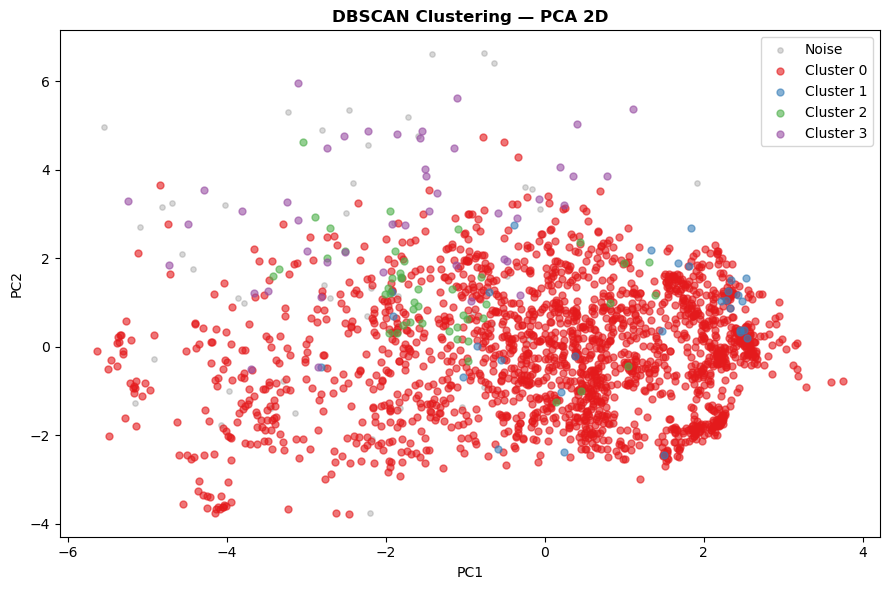

In [105]:
# Visualize DBSCAN
plt.figure(figsize=(9, 6))
unique_labels = sorted(set(labels_best))
db_palette = sns.color_palette('Set1', max(n_clusters_db, 1))

for lbl in unique_labels:
    mask = labels_best == lbl
    if lbl == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c='gray',
                    alpha=0.3, s=15, label='Noise')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=db_palette[lbl % len(db_palette)],
                    alpha=0.6, s=25, label=f'Cluster {lbl}')

plt.title('DBSCAN Clustering — PCA 2D', fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

## END : Model Comparison

In [106]:
# DBSCAN metrics excluding noise
if n_clusters_db > 1:
    mask = labels_best != -1
    
    sil_db_final = silhouette_score(X_scaled[mask], labels_best[mask])
    db_db = davies_bouldin_score(X_scaled[mask], labels_best[mask])
else:
    sil_db_final = np.nan
    db_db = np.nan

# Create comparison table
results = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'Silhouette Score ↑': [
        round(sil_km, 4),
        round(sil_agg_h, 4),
        round(sil_db_final, 4) if not np.isnan(sil_db_final) else 'N/A'
    ],
    'Davies-Bouldin ↓': [
        round(db_km, 4),
        round(db_agg_h, 4),
        round(db_db, 4) if not np.isnan(db_db) else 'N/A'
    ],
    'Clusters': [K, K, n_clusters_db]
})

print('Model Comparison:')
print(results.to_string(index=False))

Model Comparison:
              Model  Silhouette Score ↑  Davies-Bouldin ↓  Clusters
            K-Means              0.2293            2.6671         2
Hierarchical (Ward)              0.1301            3.1020         2
             DBSCAN              0.3412            1.1850         4


In [107]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=5)
pca.fit(X_scaled)
loadings = pd.DataFrame(np.abs(pca.components_).T, index=X_enco.columns)
loadings_sum = loadings.sum(axis=1).sort_values(ascending=False)
print("Top features influencing distances:")
print(loadings_sum.head(12))

Top features influencing distances:
CALC_Sometimes                  1.197536
Risk_Score                      1.194229
CALC_No                         1.178880
Age                             1.156125
MTRANS_Public_Transportation    1.095524
Height                          1.084508
CAEC_Frequently                 1.036070
FAVC_Yes                        0.947736
CAEC_Sometimes                  0.903241
Activity_Score                  0.864577
Gender_Male                     0.807585
FAF                             0.783042
dtype: float64


In [108]:
df_clean.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad', 'BMI', 'BMI_Category', 'MTRANS_score',
       'Activity_Score', 'FAVC_bin', 'CAEC_score', 'Risk_Score'],
      dtype='object')

In [109]:
X_enco.columns

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI',
       'Activity_Score', 'Risk_Score', 'Gender_Male',
       'family_history_with_overweight_Yes', 'FAVC_Yes', 'CAEC_Frequently',
       'CAEC_No', 'CAEC_Sometimes', 'SMOKE_Yes', 'SCC_Yes', 'CALC_Frequently',
       'CALC_No', 'CALC_Sometimes', 'MTRANS_Bike', 'MTRANS_Motorbike',
       'MTRANS_Public_Transportation', 'MTRANS_Walking'],
      dtype='object')

## Cluster Profiling

so based on the previous results we had chose DBSCAN as our best model for clustering

now we will check the presence of some features in each cluster in order to make interpretation and to understand each cluster characteristics

Cluster sizes (without noise):
cluster
0    1934
2      46
3      45
1      30
Name: count, dtype: int64

Cluster Profiles — Mean Values:
         Risk_Score  Activity_Score    FAF  FAVC_Yes  CAEC_Frequently  \
cluster                                                                 
0             2.023           0.838  0.994     0.893            0.108   
1             1.867           0.967  0.980     0.800            0.033   
2             0.870           1.348  1.049     0.870            0.000   
3             1.911           2.689  1.533     0.600            0.133   

         CAEC_Sometimes  CALC_Sometimes  CALC_No     Age  \
cluster                                                    
0                 0.873           0.678    0.297  24.236   
1                 0.933           1.000    0.000  28.151   
2                 0.000           0.870    0.130  23.122   
3                 0.756           0.578    0.400  20.790   

         family_history_with_overweight_Yes  
cluster         

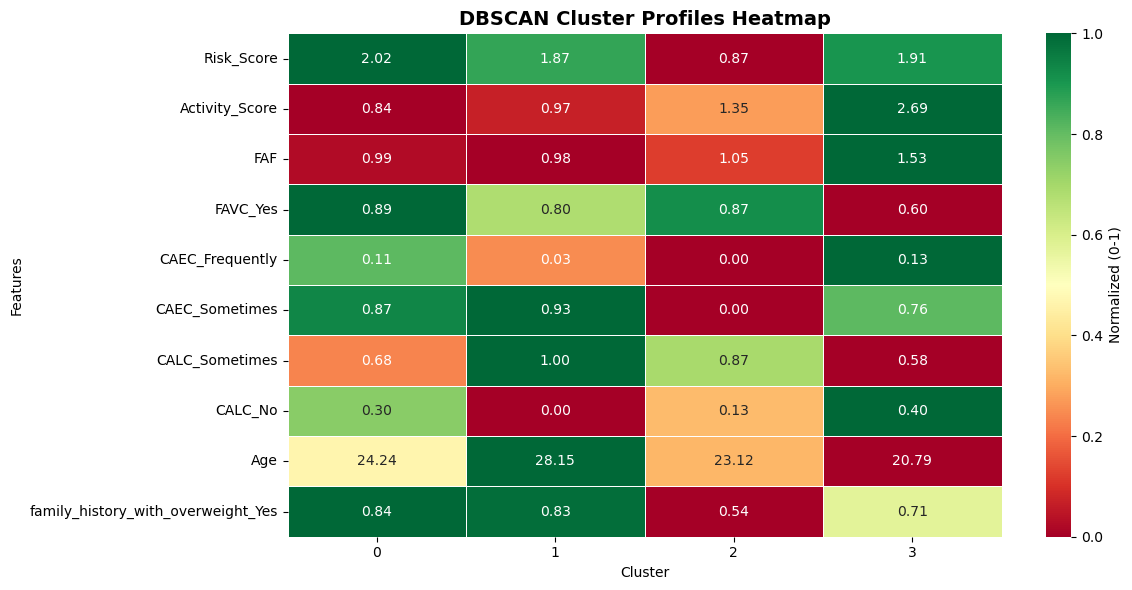

In [110]:
#DBSCAN cluster labels
X_enco['cluster'] = labels_best

# remove noise points (-1)
df_valid = X_enco[X_enco['cluster'] != -1]

print("Cluster sizes (without noise):")
print(df_valid['cluster'].value_counts())

profile_cols = [
    'Risk_Score',               # overall behavioral risk
    'Activity_Score',           # total activity score
    'FAF',                      # exercise frequency
    'FAVC_Yes',                 # high-calorie food intake
    'CAEC_Frequently',          # frequent snacking
    'CAEC_Sometimes',           # occasional snacking
    'CALC_Sometimes',           # sometimes alcohol
    'CALC_No',                  # no alcohol (contrast)
    'Age',                      # demographic factor
    'family_history_with_overweight_Yes'  # active transportation
]

# Compute cluster profiles
cluster_profiles = df_valid.groupby('cluster')[profile_cols].mean().round(3)

print('\nCluster Profiles — Mean Values:')
print(cluster_profiles)

# Normalize for heatmap
profile_norm = (cluster_profiles - cluster_profiles.min()) / \
               (cluster_profiles.max() - cluster_profiles.min())

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    profile_norm.T,
    annot=cluster_profiles.T,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized (0-1)'}
)

plt.title('DBSCAN Cluster Profiles Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Radar chart

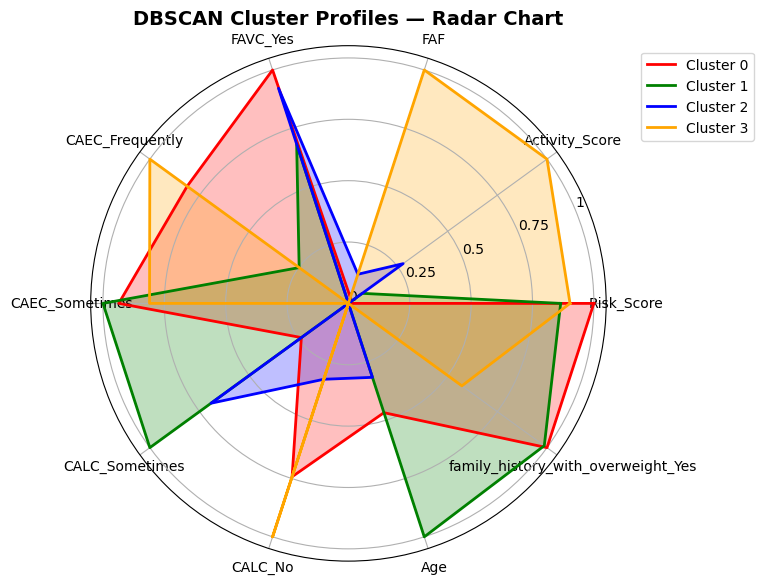

In [111]:

features = [
    'Risk_Score', 'Activity_Score', 'FAF', 
    'FAVC_Yes', 'CAEC_Frequently', 'CAEC_Sometimes', 
    'CALC_Sometimes', 'CALC_No', 'Age', 
    'family_history_with_overweight_Yes'
]

#normalize (0 → 1)

cluster_norm = (cluster_profiles[features] - cluster_profiles[features].min()) / \
               (cluster_profiles[features].max() - cluster_profiles[features].min())



#radar angles

categories = features
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  


# POLAR plot 

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)  

colors = ['r', 'g', 'b', 'orange']


# plot of  each cluster

for i, cluster_id in enumerate(cluster_norm.index):
    values = cluster_norm.loc[cluster_id].tolist()
    values += values[:1]  # close loop

    ax.plot(angles, values, color=colors[i % len(colors)], linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.25)




ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)

ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.set_yticklabels(["0", "0.25", "0.5", "0.75", "1"])

plt.title("DBSCAN Cluster Profiles — Radar Chart", fontsize=14, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.show()

using the labeled column just to test results

In [112]:
X_enco['NObeyesdad'] = df_clean['NObeyesdad'].astype(str)
X_enco = X_enco[X_enco['cluster'] != -1]

X_enco['cluster'] = X_enco['cluster'].astype(str)

crosstab = pd.crosstab(X_enco['cluster'], X_enco['NObeyesdad'], normalize='index') * 100
crosstab = crosstab.round(1)  
print('Cluster vs Obesity Label (% per cluster):')
crosstab

Cluster vs Obesity Label (% per cluster):


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
cluster,,,,,,,
0,13.4,11.5,17.5,14.4,16.6,12.4,14.3
1,3.3,26.7,6.7,46.7,3.3,3.3,10.0
2,6.5,13.0,8.7,4.3,6.5,54.3,6.5
3,8.9,60.0,4.4,2.2,0.0,11.1,13.3


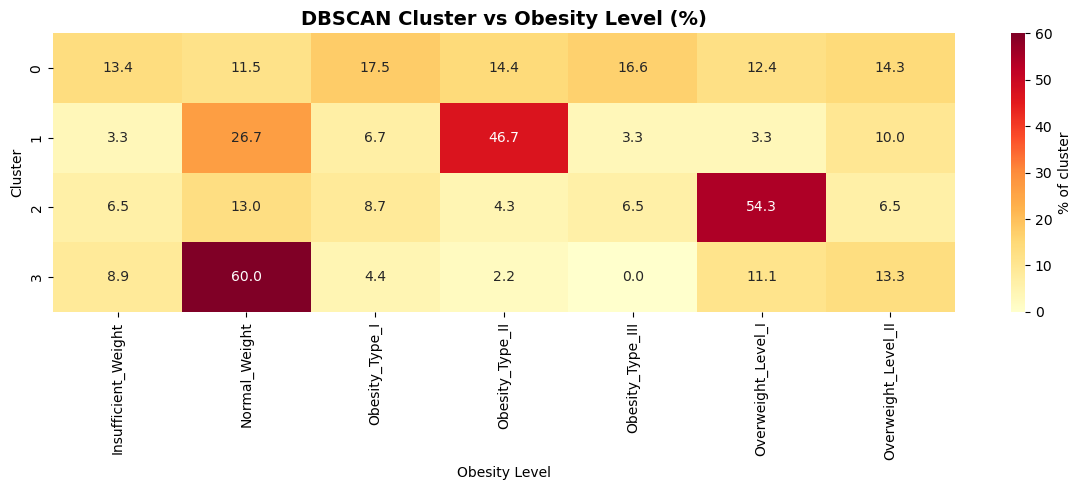

In [113]:
plt.figure(figsize=(12, 5))
sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of cluster'})
plt.title('DBSCAN Cluster vs Obesity Level (%)', fontsize=14, fontweight='bold')
plt.ylabel('Cluster')
plt.xlabel('Obesity Level')
plt.tight_layout()
plt.show()